## IMPORTS

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, mannwhitneyu

## LOADING AND MERGING TABLES

In [4]:
songs = pd.read_csv('../exports/songs.csv')
albums = pd.read_csv('../exports/albums.csv')
audio_features = pd.read_csv('../exports/song_audio_features.csv')

In [6]:
df = songs.merge(albums, on='album_id', how='inner')
df= df.merge(audio_features, on='song_id', how='inner')


## INDEXING THE TABLE TO GET DATA

In [8]:
data = df[['popularity', 'is_explicit', 'album_type', 'energy']]

## BASIC EDA

In [10]:
data.sample(10)

,popularity,is_explicit,album_type,energy
5558,15,f,album,0.14523
56856,39,f,album,0.12764
35786,34,t,album,0.24212
89617,7,f,album,0.20750
10795,52,t,album,0.20708
77500,23,f,album,0.16363
34966,59,f,album,0.13828
86522,25,f,single,0.32932
99127,48,f,album,0.13663
15054,9,f,album,0.29171


The complete dataframe and successfully indexed for only the data we require for this investigation.

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109291 entries, 0 to 109290
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   popularity   109291 non-null  int64  
 1   is_explicit  109291 non-null  object 
 2   album_type   109291 non-null  object 
 3   energy       109291 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.3+ MB


No missing values!

## CHANGING DATA TYPES

In [15]:
data['is_explicit']=data['is_explicit'].map({'t':1, 'f':0})

/var/folders/9v/g0l2v7dn7b72486f6lzl24f40000gn/T/ipykernel_17006/450351015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['is_explicit']=data['is_explicit'].map({'t':1, 'f':0})


In [18]:
data['album_type'] = data['album_type'].map({'album': 0, 'single': 1, 'compilation':2})

/var/folders/9v/g0l2v7dn7b72486f6lzl24f40000gn/T/ipykernel_17006/3830295210.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['album_type'] = data['album_type'].map({'album': 0, 'single': 1, 'compilation':2})


## FILTERING DATA

In [20]:
data = data[data['album_type']!=2]

We only want data for albums or singles, not compilations.

In [22]:
data['album_type'].value_counts()

album_type
0    66086
1    38495
Name: count, dtype: int64

As shown by the value counts, compilations(2) were removed.

In [27]:
data.duplicated().sum()

np.int64(0)

In [26]:
data =data.drop_duplicates()

## Do Explicit Songs Perform Differently Than Clean Songs?

### Hypotheses
* H0: Explicit songs and clean songs have the same average popualarity.
* H1: Explicit songs have a different average popularity than clean songs.
* Alpha: .05 (is p < .05 than we reject H0)

### Groups
* Explicit songs = 1
* Clean Songs = 0
* Outcome: song popularity (data['popularity'])


In [30]:
explicit = data[data['is_explicit']==1]['popularity']
clean = data[data['is_explicit']==0]['popularity']


In [31]:
explicit.describe()

count    24495.000000
mean        29.463523
std         20.115746
min          1.000000
25%         12.000000
50%         27.000000
75%         45.000000
max         92.000000
Name: popularity, dtype: float64

In [32]:
clean.describe()

count    78781.000000
mean        28.913888
std         19.175077
min          1.000000
25%         13.000000
50%         26.000000
75%         43.000000
max         99.000000
Name: popularity, dtype: float64

The observations from the two summary tables gives us insights into the potential similarities and differences between the two groups. The size of the explicit table is roughly 1/3 the size of the clean table meaning that my dataset contains many more clean songs than explicit ones. This is important to note because the sheer size difference may cause bias in my analysis later on. The mean of both datasets looks relatively similar with the explicit dataset having a mean popularity score of 29.46 and the clean dataset having a mean song popularity score of 28.91. That is a mere different of .55 in average song popularity score. Additionally the standard deviations are similar as well with the explicit data having a std of 20.11 and the clean dataset having a std of 19.17. Without having visualized and tested the datasets they appear to be more similar than they are different. Additionally, the distribution (the quartiles) of data follows a similar pattern. 

## CHECK FOR NORMALITY

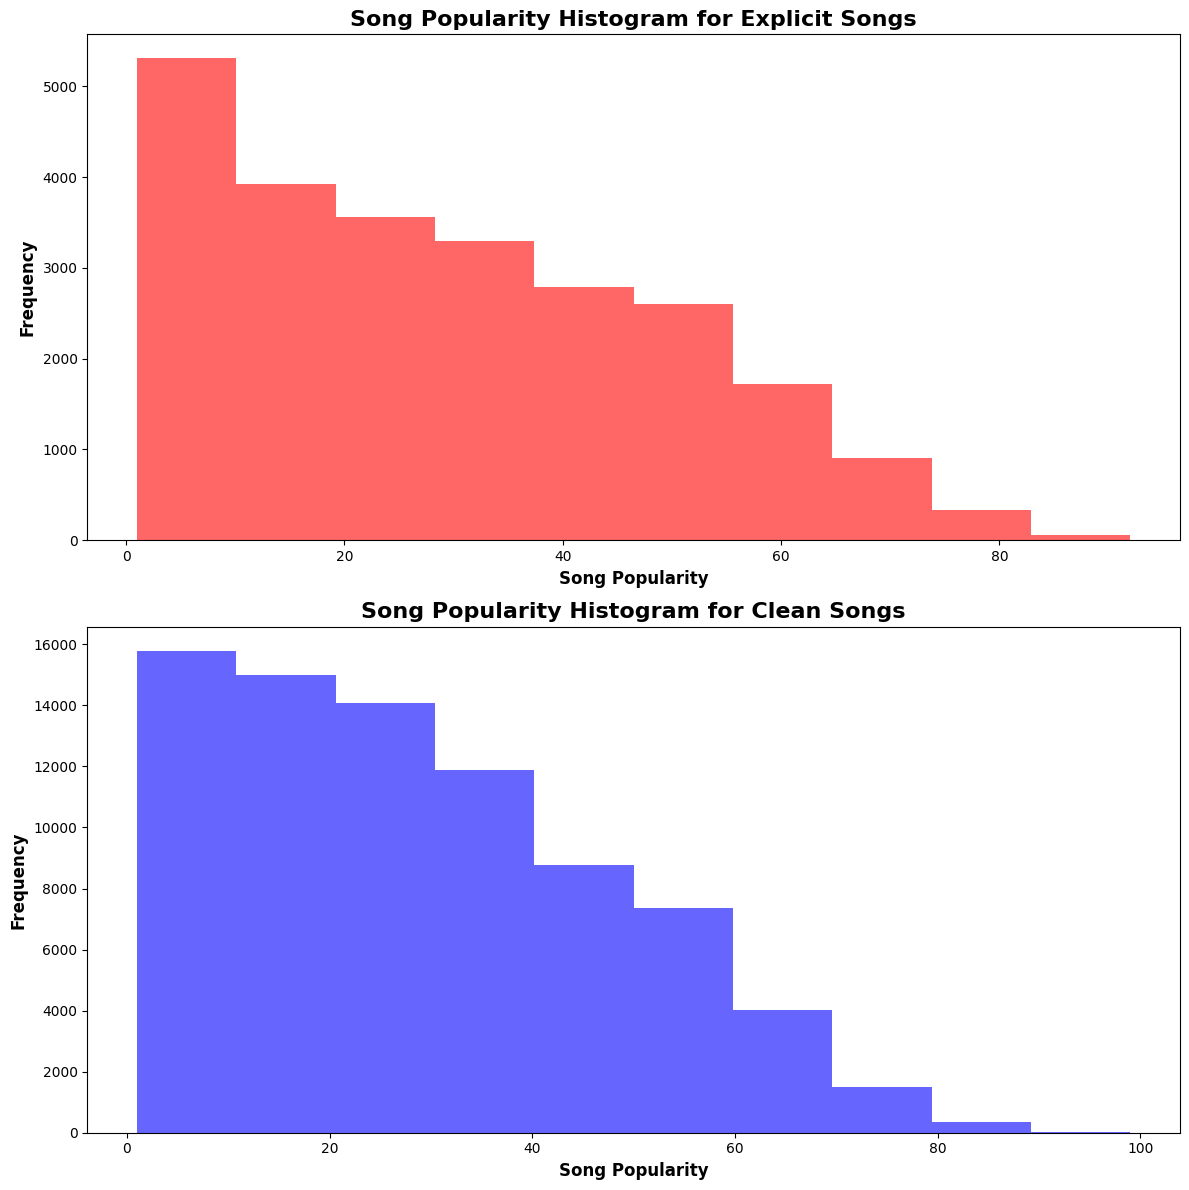

In [49]:
fig, axes=plt.subplots(2,1, figsize=(12,12))

axes[0].hist(explicit, color='red',alpha=.6)
axes[0].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Song Popularity Histogram for Explicit Songs', fontsize=16, fontweight='bold')

axes[1].hist(clean, color='blue',alpha=.6)
axes[1].set_xlabel('Song Popularity', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Song Popularity Histogram for Clean Songs', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [42]:
_ , p_exp = shapiro(explicit.sample(500, random_state=42))
_, p_clean = shapiro(clean.sample(500, random_state=42))

print(f'Shapiro-Wilk - explicit p: {p_exp:.4f}')
print(f'Shapiro-Wilk - clean p: {p_clean:.4f}')

Shapiro-Wilk - explicit p: 0.0000
Shapiro-Wilk - clean p: 0.0000


As seen by the graphs and corroborated by the Shaprio-Wilks test, my data for both datasets is not normally distributed. Both graphs show a heavily skewed-right distrbution with a long tail. This violates the assumption of normal distributions that they are bell-shaped. Additionally, the Shapiro-Wilks tests returned a p-value that was less than .05 so we reject normality. We ran the Shapiro-Wilks test on a smaller sample because due to the large size of my data, a small deviation could greatly impact the results. All in all, we cannot use a two-tailed T-test since one of the assumptions of a t-test is that the data must be normally distrbuted.

##

## MANN WHITNEY U TEST

In [52]:
stat, p_val = mannwhitneyu(explicit, clean, alternative='two-sided')
print(f"p = {p_val:.6f}")

p = 0.024774


With a p-value of .024 we can reject the null hypothesis and conclude that the two datasets' (explicit & clean) average song popularity are statistically different from each other. 

## COHEN'S D

In [ ]:
def cohens_d(std1, std2, mean1, mean2):
    pooled_sqrt = np.sqrt((std1**2+std2**2)/2)
    cohens_d = ((mean1-mean2)/pooled_sqrt)

        
    if abs(cohens_d) < 0.2:
        print("Effect size: Negligible")
    elif abs(cohens_d) < 0.5:
        print("Effect size: Small")
    elif abs(cohens_d) < 0.8:
        print("Effect size: Medium")
    else:
        print("Effect size: Large")
